In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Model
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import os
import random
from PIL import Image

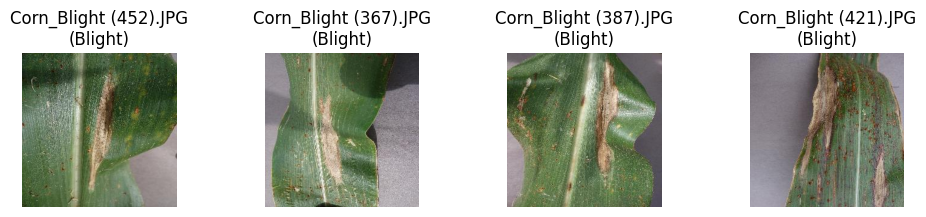

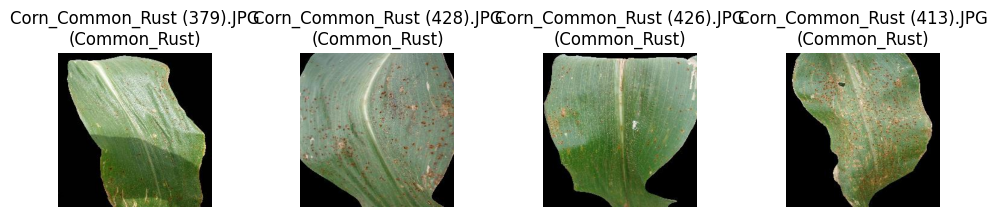

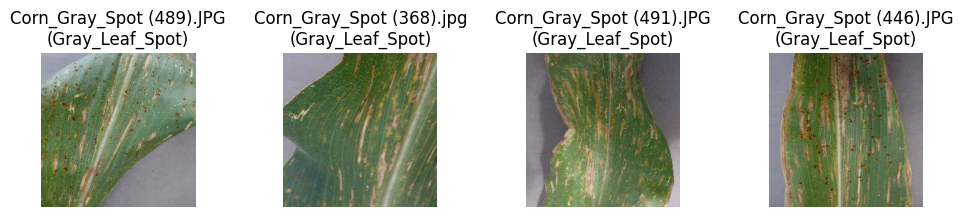

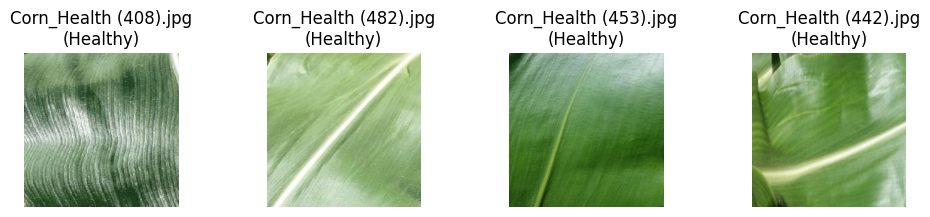

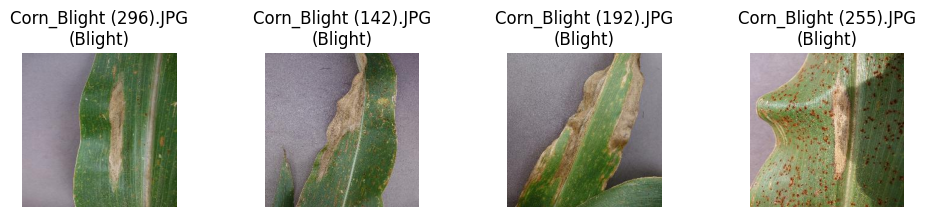

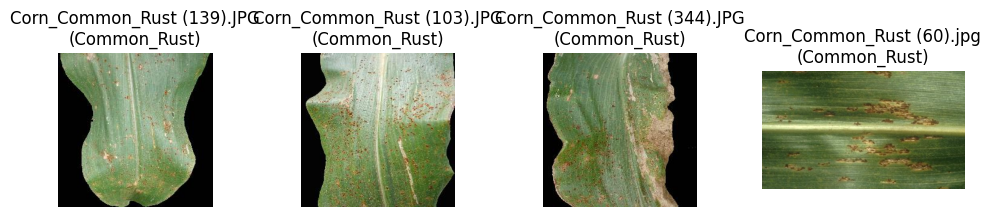

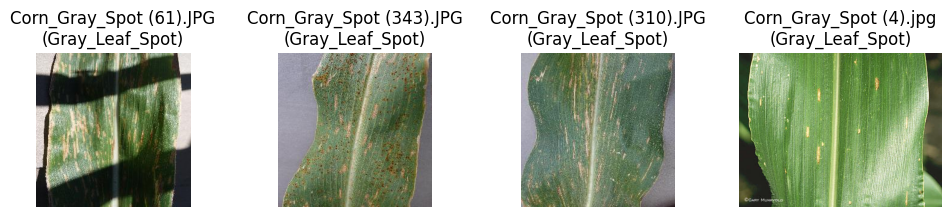

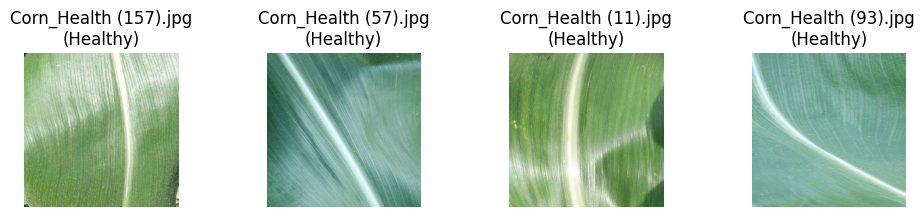

In [2]:
def random_photos_from_folders(base_folder):
    for root, dirs, files in os.walk(base_folder):
        images = [file for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) >= 4:  
            selected_images = random.sample(images, 4)  
            
            fig, axs = plt.subplots(1, 4, figsize=(12, 2))  
            for idx, img_name in enumerate(selected_images):
                img_path = os.path.join(root, img_name)
                img = Image.open(img_path)
                axs[idx].imshow(img)
                axs[idx].axis('off') 
                
                subfolder_name = os.path.basename(root)
                axs[idx].set_title(f"{img_name}\n({subfolder_name})")
                
            plt.show()

path='dataset'
random_photos_from_folders(path)

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=30, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    fill_mode='nearest')

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)  


In [5]:
training_set = train_datagen.flow_from_directory(r'dataset/train',
                                                target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='categorical')

Found 1400 images belonging to 4 classes.


In [6]:
test_set = train_datagen.flow_from_directory(r'dataset/test',
                                                target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='categorical',
                                                shuffle=False
                                                )

Found 600 images belonging to 4 classes.


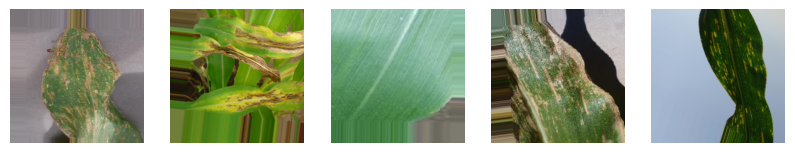

In [7]:
images, labels = next(training_set)  

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])  
    plt.axis("off") 
plt.show()

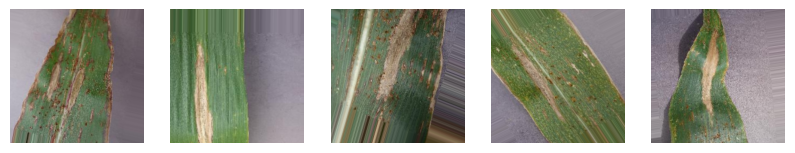

In [8]:
images, labels = next(test_set)  

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])  
    plt.axis("off") 
plt.show()

In [9]:
inception_v3 = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [10]:
for layer in inception_v3.layers[: -15]:
    layer.trainable = False

In [11]:
from tensorflow.keras.regularizers import l2

x = Flatten()(inception_v3.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)  # Increased dropout
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=inception_v3.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 48,282,404 (184.18 MB)

 Trainable params: 26,874,500 (102.52 MB)

 Non-trainable params: 21,407,904 (81.66 MB)

In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
histry = model.fit(training_set,
                            validation_data=test_set,
                            epochs=35,
                            steps_per_epoch=len(training_set),
                            validation_steps=len(test_set),
                            )

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 213s 5s/step - accuracy: 0.4798 - loss: 10.8904 - val_accuracy: 0.8200 - val_loss: 2.6559
Epoch 2/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.7083 - loss: 3.2648 - val_accuracy: 0.8267 - val_loss: 2.0997
Epoch 3/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.7243 - loss: 2.4043 - val_accuracy: 0.8583 - val_loss: 1.8854
Epoch 4/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.7538 - loss: 2.1668 - val_accuracy: 0.8500 - val_loss: 1.7833
Epoch 5/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.7766 - loss: 1.9385 - val_accuracy: 0.8967 - val_loss: 1.5561
Epoch 6/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 174s 4s/step - accuracy: 0.8109 - loss: 1.7419 - val_accuracy: 0.8583 - val_loss: 1.5431
Epoch 7/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.7820 - loss: 1.6513 - val_accuracy: 0.8783 - val_loss: 1.4254
Epoch 8/35
44/44 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.7873 - loss: 1.5672 - val_accuracy: 0.8417 - 

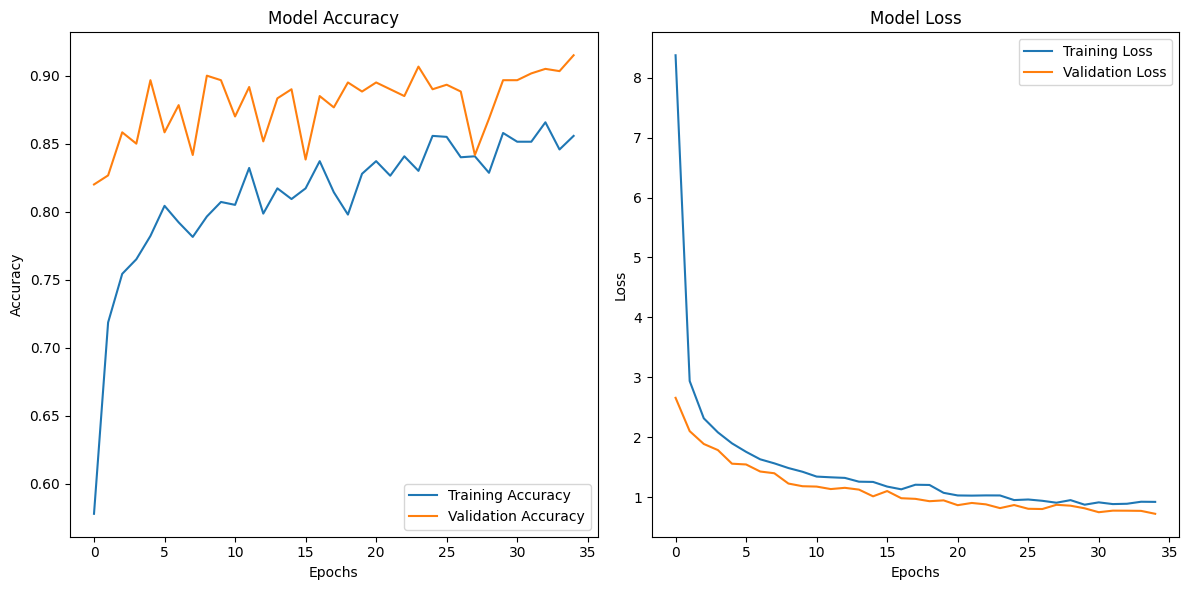

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(histry.history['accuracy'], label='Training Accuracy')
plt.plot(histry.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(histry.history['loss'], label='Training Loss')
plt.plot(histry.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
model.save("maze_model.h5")